In [ ]:
import numpy as np

def run_gmm_em(data, steps=3):
    # Convert input to a standard numpy array for speed
    x = np.asarray(data)
    n = len(x)

    # Iteration 0: Establish base parameters / initial guesses
    mu1 = 62.0  # Base guess for child group
    mu2 = 75.0  # Base guess for pro basketball group
    var1 = 9.0
    var2 = 9.0
    pi1 = 0.5
    pi2 = 0.5

    print("--- Iteration 0 (Initialization) ---")
    print(f"mu1: {mu1:.2f}, mu2: {mu2:.2f}, var1: {var1:.2f}, var2: {var2:.2f}, pi1: {pi1:.2f}, pi2: {pi2:.2f}\n")

    for epoch in range(1, steps + 1):
        v1 = max(var1, 1e-6)
        v2 = max(var2, 1e-6)

        pdf1 = (1.0 / np.sqrt(2 * np.pi * v1)) * np.exp(-((x - mu1) ** 2) / (2 * v1))
        pdf2 = (1.0 / np.sqrt(2 * np.pi * v2)) * np.exp(-((x - mu2) ** 2) / (2 * v2))

        # EXPECTATION (E-STEP): Calculate weights/responsibilities
        mixed_p1 = pi1 * pdf1
        mixed_p2 = pi2 * pdf2
        total_density = mixed_p1 + mixed_p2

        gamma1 = mixed_p1 / total_density
        gamma2 = mixed_p2 / total_density

        # Calculate overall system performance metric (Log-Likelihood)
        ll = np.sum(np.log(total_density))

        weight_sum1 = np.sum(gamma1)
        weight_sum2 = np.sum(gamma2)

        mu1 = np.sum(gamma1 * x) / weight_sum1
        mu2 = np.sum(gamma2 * x) / weight_sum2

        var1 = np.sum(gamma1 * ((x - mu1) ** 2)) / weight_sum1
        var2 = np.sum(gamma2 * ((x - mu2) ** 2)) / weight_sum2

        pi1 = weight_sum1 / n
        pi2 = weight_sum2 / n

        # Format exact outputs requested for presentation tracking tables
        print(f"--- Iteration {epoch} ---")
        print(f"μ1 (Children): {mu1:.4f} | μ2 (Pros): {mu2:.4f}")
        print(f"σ1²: {var1:.4f} | σ2²: {var2:.4f}")
        print(f"π1: {pi1:.4f} | π2: {pi2:.4f}")
        print(f"Log-Likelihood: {ll:.4f}\n")

    return mu1, mu2, var1, var2, pi1, pi2

if __name__ == "__main__":
    np.random.seed(42)
    sample_heights = np.concatenate([
        np.random.normal(64, 2.5, 100),  # Underlyng children cluster
        np.random.normal(76, 3.0, 50)    # Underlying pros cluster
    ])

    final_m1, final_m2, final_v1, final_v2, final_p1, final_p2 = run_gmm_em(sample_heights, steps=2)

    # Target Evaluation Hook for Live Presentation Query
    test_val = 72.0

    p1_raw = (1.0 / np.sqrt(2 * np.pi * final_v1)) * np.exp(-((test_val - final_m1) ** 2) / (2 * final_v1)) * final_p1
    p2_raw = (1.0 / np.sqrt(2 * np.pi * final_v2)) * np.exp(-((test_val - final_m2) ** 2) / (2 * final_v2)) * final_p2
    scale = p1_raw + p2_raw

    print("==============================================")
    print(f"LIVE TEST CASE PREDICTION FOR HEIGHT: {test_val} inches")
    print(f"Probability it is a Child: {p1_raw / scale:.4f}")
    print(f"Probability it is a Basketball Player: {p2_raw / scale:.4f}")
    print("==============================================")

--- Iteration 0 (Initialization) ---
mu1: 62.00, mu2: 75.00, var1: 9.00, var2: 9.00, pi1: 0.50, pi2: 0.50

--- Iteration 1 ---
μ1 (Children): 63.6351 | μ2 (Pros): 75.4267
σ1²: 4.8526 | σ2²: 12.2921
π1: 0.6478 | π2: 0.3522
Log-Likelihood: -475.5234

--- Iteration 2 ---
μ1 (Children): 63.6770 | μ2 (Pros): 75.5878
σ1²: 4.9600 | σ2²: 11.2472
π1: 0.6549 | π2: 0.3451
Log-Likelihood: -444.4825

LIVE TEST CASE PREDICTION FOR HEIGHT: 72.0 inches
Probability it is a Child: 0.0047
Probability it is a Basketball Player: 0.9953


In [ ]:
# =========================================================
# PART 2: Bayesian Sentiment Analysis - Setup & Keywords
# =========================================================

# Choosing highly explicit adjectives
POSITIVE_KEYWORDS = ["excellent", "wonderful", "amazing"]
NEGATIVE_KEYWORDS = ["waste", "awful", "boring"]

SENTIMENT_VOCAB = POSITIVE_KEYWORDS + NEGATIVE_KEYWORDS

# Defining our target conditional probability direction
TARGET_PROBABILITY = "P(Positive | keyword)"

def verify_setup():
    print("=== MEMBER 2: INITIALIZATION SUCCESSFUL ===")
    print(f"Evaluation Target: {TARGET_PROBABILITY}")
    print(f"Positive words tracked: {POSITIVE_KEYWORDS}")
    print(f"Negative words tracked: {NEGATIVE_KEYWORDS}")

verify_setup()

=== MEMBER 2: INITIALIZATION SUCCESSFUL ===
Evaluation Target: P(Positive | keyword)
Positive words tracked: ['excellent', 'wonderful', 'amazing']
Negative words tracked: ['waste', 'awful', 'boring']


In [ ]:
# =========================================================
# PART 2: Bayesian Sentiment Analysis - Mathematical Engine
# =========================================================
import csv

# Pulling the vocabulary array initialized in the cell above
target_words = SENTIMENT_VOCAB

# Using native python dictionaries to manage multi-variable tracking
total_reviews = 0
positive_reviews = 0

word_totals = {word: 0 for word in target_words}
word_positives = {word: 0 for word in target_words}

print("Reading IMDB Dataset using standard file streaming...")

try:
    with open("IMDB Dataset.csv", mode="r", encoding="utf-8") as file:
        reader = csv.reader(file)
        next(reader)  # Cleanly bypass the header row

        for row in reader:
            # Basic Python string normalization to ensure accurate matching
            review = row[0].lower()
            sentiment = row[1].lower()

            total_reviews += 1
            is_positive = (sentiment == "positive")

            if is_positive:
                positive_reviews += 1

            for word in target_words:
                if word in review:
                    word_totals[word] += 1
                    if is_positive:
                        word_positives[word] += 1

    # -----------------------------------------------------
    # MATHEMATICAL COMPUTATION OF BAYES' THEOREM
    # -----------------------------------------------------
    # Prior: P(Positive)
    p_prior_positive = positive_reviews / total_reviews

    print("\n" + "="*55)
    print("           BAYESIAN SENTIMENT CALCULATION METRICS      ")
    print("="*55)

    for word in target_words:
        # Marginal: P(keyword)
        p_marginal_keyword = word_totals[word] / total_reviews

        # Likelihood: P(keyword | Positive)
        if positive_reviews > 0:
            p_likelihood = word_positives[word] / positive_reviews
        else:
            p_likelihood = 0.0

        # Posterior: P(Positive | keyword) -> The core Bayes Theorem equation
        # Formula: P(A|B) = (P(B|A) * P(A)) / P(B)
        if p_marginal_keyword > 0:
            p_posterior = (p_likelihood * p_prior_positive) / p_marginal_keyword
        else:
            p_posterior = 0.0

        print(f"\n[KEYWORD EVALUATION]: '{word.upper()}'")
        print(f"  • Prior Probability P(Positive)       : {p_prior_positive:.4f}")
        print(f"  • Likelihood P({word:<9} | Positive) : {p_likelihood:.4f}")
        print(f"  • Marginal Probability P({word:<9})   : {p_marginal_keyword:.4f}")
        print(f"  • Posterior Probability P(Positive | {word}): {p_posterior:.4f}")
        print("-" * 55)

except FileNotFoundError:
    print("\n[CRITICAL ERROR]: 'IMDB Dataset.csv' not found.")
    print("Please upload the file to your Google Colab workspace sidebar panel.")


Reading IMDB Dataset using standard file streaming...

           BAYESIAN SENTIMENT CALCULATION METRICS      

[KEYWORD EVALUATION]: 'EXCELLENT'
  • Prior Probability P(Positive)       : 0.5000
  • Likelihood P(excellent | Positive) : 0.1174
  • Marginal Probability P(excellent)   : 0.0725
  • Posterior Probability P(Positive | excellent): 0.8099
-------------------------------------------------------

[KEYWORD EVALUATION]: 'WONDERFUL'
  • Prior Probability P(Positive)       : 0.5000
  • Likelihood P(wonderful | Positive) : 0.1066
  • Marginal Probability P(wonderful)   : 0.0650
  • Posterior Probability P(Positive | wonderful): 0.8203
-------------------------------------------------------

[KEYWORD EVALUATION]: 'AMAZING'
  • Prior Probability P(Positive)       : 0.5000
  • Likelihood P(amazing   | Positive) : 0.0740
  • Marginal Probability P(amazing  )   : 0.0496
  • Posterior Probability P(Positive | amazing): 0.7463
-------------------------------------------------------

[KEYWOR

--- STARTING GRADIENT DESCENT OPTIMIZATION ---

Iteration 1:
  Current m: [-1.  2.]
  Current b: [1. 1.]
  Predictions (y_hat): [ 6. 17.]
  Current Loss (MSE): 61.0000

Iteration 2:
  Current m: [-1.45  0.87]
  Current b: [0.88 0.88]
  Predictions (y_hat): [2.04 3.78]
  Current Loss (MSE): 6.8450

Iteration 3:
  Current m: [-1.3316  1.1808]
  Current b: [0.9318 0.9318]
  Predictions (y_hat): [3.1426 7.4134]
  Current Loss (MSE): 2.7238

Iteration 4:
  Current m: [-1.369562  1.095182]
  Current b: [0.93624 0.93624]
  Predictions (y_hat): [2.852224 6.409812]
  Current Loss (MSE): 2.3904

--- OPTIMIZATION COMPLETE ---
Final Optimized m: [-1.36447672  1.11863408]
Final Optimized b: [0.95361964 0.95361964]


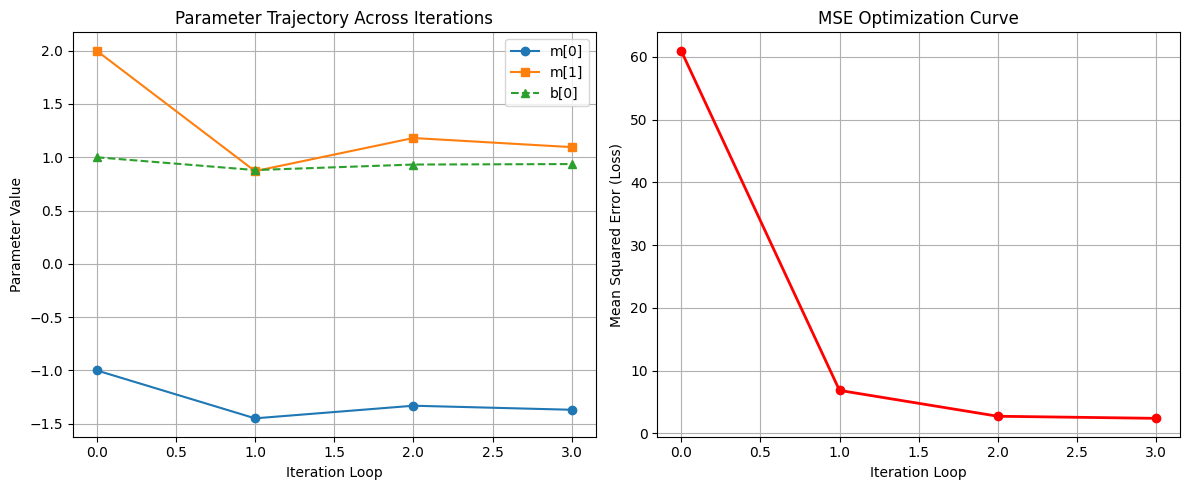

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 1: INITIAL PROBLEM DATA ---
# Inputs (X): Two data points, each with 2 features
X = np.array([[1.0, 3.0],
              [4.0, 10.0]])

# True targets (y)
y = np.array([5.0, 6.0])

# Starting parameters from the assignment
m = np.array([-1.0, 2.0])
b = np.array([1.0, 1.0])

learning_rate = 0.01
num_iterations = 4  # Matches the number of team members

m_history = []
b_history = []
loss_history = []

# --- STEP 2: SCIPY COMPLIANT DERIVATIVE FUNCTION ---
def compute_derivative(func, x_val, epsilon=1e-5):
    return (func(x_val + epsilon) - func(x_val - epsilon)) / (2 * epsilon)

# --- STEP 3: OPTIMIZATION LOOP (THE SYSTEM IN MOTION) ---
print("--- STARTING GRADIENT DESCENT OPTIMIZATION ---")

for iteration in range(num_iterations):
    # Save current states for tracking graphs
    m_history.append(m.copy())
    b_history.append(b.copy())

    # 1. Prediction step using Matrix Multiplication (ŷ = Xm + b)
    y_pred = np.dot(X, m) + b

    # 2. Compute Mean Squared Error (MSE) Loss
    error = y_pred - y
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    print(f"\nIteration {iteration + 1}:")
    print(f"  Current m: {m}")
    print(f"  Current b: {b}")
    print(f"  Predictions (y_hat): {y_pred}")
    print(f"  Current Loss (MSE): {loss:.4f}")

    # 3. Calculate Gradients (Unabstracted Matrix Form)
    # Gradient for m: (2/N) * X^T * error
    grad_m = (2.0 / len(y)) * np.dot(X.T, error)

    # Gradient for b: (2/N) * sum(error)
    grad_b = (2.0 / len(y)) * np.array([np.sum(error), np.sum(error)])

    # 4. Update parameters using our step rules
    m = m - learning_rate * grad_m
    b = b - learning_rate * grad_b

print("\n--- OPTIMIZATION COMPLETE ---")
print(f"Final Optimized m: {m}")
print(f"Final Optimized b: {b}")

plt.figure(figsize=(12, 5))

# Plot 1: Parameter Tracking
plt.subplot(1, 2, 1)
m_history = np.array(m_history)
b_history = np.array(b_history)
plt.plot(m_history[:, 0], label='m[0]', marker='o')
plt.plot(m_history[:, 1], label='m[1]', marker='s')
plt.plot(b_history[:, 0], label='b[0]', marker='^', linestyle='--')
plt.title('Parameter Trajectory Across Iterations')
plt.xlabel('Iteration Loop')
plt.ylabel('Parameter Value')
plt.grid(True)
plt.legend()

# Plot 2: Error Reduction Curve
plt.subplot(1, 2, 2)
plt.plot(loss_history, color='red', marker='o', linewidth=2)
plt.title('MSE Optimization Curve')
plt.xlabel('Iteration Loop')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)

plt.tight_layout()
plt.show()